In [1]:
# 데이터 처리 및 분석
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # maxOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'
    
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 시드 설정
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

SB_DEEP_GREEN = '#1E3932'
SB_GREEN      = '#006241'
SB_LIGHT_GREEN = '#D4E9E2'
SB_GOLD       = '#CBA258'
SB_GREY       = '#A2AAAD'
SB_BLACK      = '#27251F'

plt.rcParams.update({
    'font.family': 'Malgun Gothic',
    'axes.unicode_minus': False,
    'text.color': SB_BLACK,
    'axes.labelcolor': SB_BLACK,
    'xtick.color': SB_BLACK,
    'ytick.color': SB_BLACK,
    'axes.spines.top': False,    
    'axes.spines.right': False, 
    'patch.edgecolor': 'none'    
})


sns.set_palette([SB_GREEN, SB_GOLD, SB_DEEP_GREEN, SB_LIGHT_GREEN, SB_GREY])

In [3]:
merge_df = pd.read_csv("../../Data/merged_df_260325.csv")

In [4]:
trans_df = pd.read_csv("../../Data/transactions_260325.csv")

In [5]:
import pandas as pd
import ast

# 1. trans_df에 'final_label' 컬럼 생성 (다중오퍼 및 개별 오퍼 라벨링)
def get_correct_label(row):
    # 종류가 다른 오퍼들이 섞인 경우 (tx_offer_type이 multi인 경우)
    if row.get('tx_offer_type') == 'multi':
        return '다중오퍼'
    # bogo나 discount 계열 내에서 여러 오퍼를 동시에 완료한 경우
    elif row.get('tx_offer_type') in ['bogo', 'discount']:
        try:
            labels = ast.literal_eval(row['reward_offer_label_list'])
            if len(labels) > 1:
                return '다중오퍼'
            elif len(labels) == 1:
                return labels[0]
        except:
            pass
    return '일반결제'

# trans_df에 'final_label' 컬럼을 직접 생성합니다.
trans_df['final_label'] = trans_df.apply(get_correct_label, axis=1)

# 2. 생성된 final_label을 바탕으로 master_df(전체 퍼널 데이터) 구성
# trans_df에서 '다중오퍼'로 판명된 결제들의 사람/시간 정보 추출
multi_txn_info = trans_df[trans_df['final_label'] == '다중오퍼'][['person', 'time']].drop_duplicates()
multi_txn_info['is_multi_txn'] = True

# merge_df의 완료 이벤트와 엮어서 '다중오퍼 경로' 키(key) 추출
completions = merge_df[merge_df['event'] == 'completed']
multi_path = pd.merge(completions, multi_txn_info, on=['person', 'time'], how='inner')
multi_path_keys = multi_path[['person', 'offer_id', 'receive_seq']].drop_duplicates()
multi_path_keys['is_multi_path'] = True

# merge_df 전체(인포메이셔널 제외)에 'final_label' 장착
master_df = merge_df[~merge_df['offer_label'].str.contains('informational', na=False)].copy()
master_df = pd.merge(master_df, multi_path_keys, on=['person', 'offer_id', 'receive_seq'], how='left')

# 다중오퍼 경로면 '다중오퍼', 아니면 기존 오퍼 분류 적용
master_df['final_label'] = master_df.apply(
    lambda x: '다중오퍼' if x['is_multi_path'] == True else x['offer_label'], axis=1
)

In [6]:
# 1. 전체 매출액 계산 (merge_df의 모든 transaction 합계)
total_sales_val = merge_df[merge_df['event'] == 'transaction']['amount'].sum()

# 2. 오퍼 연계 매출액 계산 (trans_df에서 '다중오퍼'나 'bogo_n', 'discount_n'들의 합계)
# '일반결제' 혹은 '일반 결제'라고 이름 붙은 것들을 제외한 모든 매출
offer_sales_val = trans_df[~trans_df['final_label'].str.contains('일반', na=False)]['amount'].sum()

# 3. 산출된 진짜 일반 결제액 (전체 - 오퍼)
calculated_normal_sales = total_sales_val - offer_sales_val

# 4. 시각화용 데이터프레임 업데이트
# 10개 카테고리 매출을 새로 집계합니다.
rev_10_data = trans_df[~trans_df['final_label'].str.contains('일반', na=False)].groupby('final_label')['amount'].sum().reset_index()

# 여기에 일반 결제 한 줄을 추가
normal_row = pd.DataFrame({'final_label': ['일반 결제'], 'amount': [calculated_normal_sales]})
total_rev_10 = pd.concat([rev_10_data, normal_row], ignore_index=True)

# 5. 순서 정렬 (띄어쓰기 고정)
order_10 = ['bogo_1', 'bogo_2', 'bogo_3', 'bogo_4', 'discount_1', 'discount_2', 'discount_3', 'discount_4', '다중오퍼', '일반 결제']
total_rev_10['final_label'] = pd.Categorical(total_rev_10['final_label'], categories=order_10, ordered=True)
total_rev_10 = total_rev_10.sort_values('final_label')

1. 오퍼별 8종

In [7]:
# 1. 발송/열람/완료  계산

# master_df에서 이벤트별로 개수 세기 (피벗 테이블 활용)
funnel_df = master_df.groupby(['final_label', 'event']).size().unstack(fill_value=0)

# 필요한 컬럼만 가져와서 이름붙이기 
funnel_df = funnel_df[['received', 'viewed', 'completed']]
funnel_df.columns = ['총발송수', '총열람수', '총완료수']

# 9종 오퍼 보기 좋게 순서 정렬
order = ['bogo_1', 'bogo_2', 'bogo_3', 'bogo_4', 'discount_1', 'discount_2', 'discount_3', 'discount_4', '다중오퍼']
funnel_df = funnel_df.reindex(order)

# 결과 확인
display(funnel_df)

,총발송수,총열람수,총완료수
final_label,,,
bogo_1,7078,6249,3055
bogo_2,7124,6848,2832
bogo_3,7001,3826,3627
bogo_4,7035,6759,3726
discount_1,6894,2395,2560
discount_2,7012,6737,4476
discount_3,6862,6639,4526
discount_4,6966,3743,3296
다중오퍼,5070,3698,5084


In [8]:
# 2. 매출 및 효율 계산

# 일반 결제를 제외한 '오퍼 연계 결제'만 필터링
offer_txns = trans_df[trans_df['final_label'] != '일반결제']

# 총매출, 거래횟수, 결제인원수 한 번에 묶어서 계산!
efficiency_df = pd.DataFrame({
    '총매출': offer_txns.groupby('final_label')['amount'].sum(),
    '거래횟수': offer_txns.groupby('final_label').size(),
    '결제인원수': offer_txns.groupby('final_label')['person'].nunique() # 중복 없는 순수 인원수!
})

# 발송 1건당 매출 & 객단가(인당 매출) 계산 (위에서 만든 funnel_df 활용!)
efficiency_df['발송1건당_매출'] = efficiency_df['총매출'] / funnel_df['총발송수']
efficiency_df['객단가'] = efficiency_df['총매출'] / efficiency_df['결제인원수']

# 순서 정렬
efficiency_df = efficiency_df.reindex(order)

# 결과 확인
display(efficiency_df)

,총매출,거래횟수,결제인원수,발송1건당_매출,객단가
final_label,,,,,
bogo_1,72251.56,3055,2690,10.207906,26.859316
bogo_2,66567.32,2832,2494,9.344093,26.690986
bogo_3,62767.30,3627,3230,8.965476,19.432601
bogo_4,70338.90,3726,3304,9.998422,21.289013
discount_1,63811.75,2566,2320,9.256129,27.505065
discount_2,74350.56,4478,3915,10.603331,18.991203
discount_3,79538.92,4530,3944,11.591215,20.167069
discount_4,65247.52,3298,2935,9.366569,22.230842
다중오퍼,61749.85,2505,2410,12.179458,25.622344


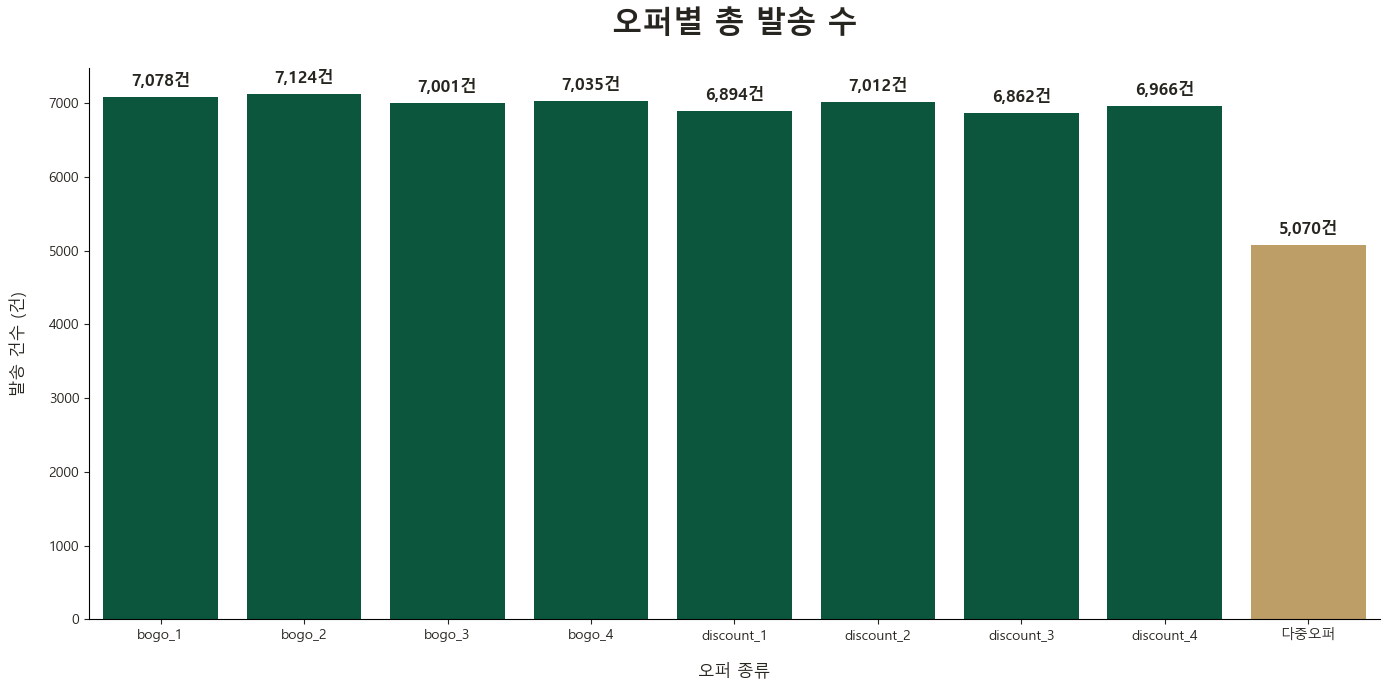

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 스타벅스 테마 컬러 세팅
SB_GREEN = '#006241'
SB_GOLD  = '#CBA258'
SB_BLACK = '#27251F'

plt.rcParams.update({'font.family': 'Malgun Gothic', 'axes.unicode_minus': False})

plt.figure(figsize=(14, 7))

# funnel_df의 인덱스('final_label')를 컬럼으로 꺼내서 사용합니다.
plot_data = funnel_df.reset_index()

# 카테고리별 색상 배정 
colors = [SB_GOLD if cat == '다중오퍼' else SB_GREEN for cat in plot_data['final_label']]

# 막대그래프 그리기
ax = sns.barplot(data=plot_data, x='final_label', y='총발송수', palette=colors)

# 제목 및 라벨
plt.title('오퍼별 총 발송 수', fontsize=22, fontweight='bold', pad=25)
plt.xlabel('오퍼 종류', fontsize=12, labelpad=15)
plt.ylabel('발송 건수 (건)', fontsize=12, labelpad=15)

# 막대 위에 숫자 달아주기
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}건", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', xytext=(0, 5), 
                textcoords='offset points', fontsize=12, fontweight='bold', color=SB_BLACK)

plt.tight_layout()
plt.show()

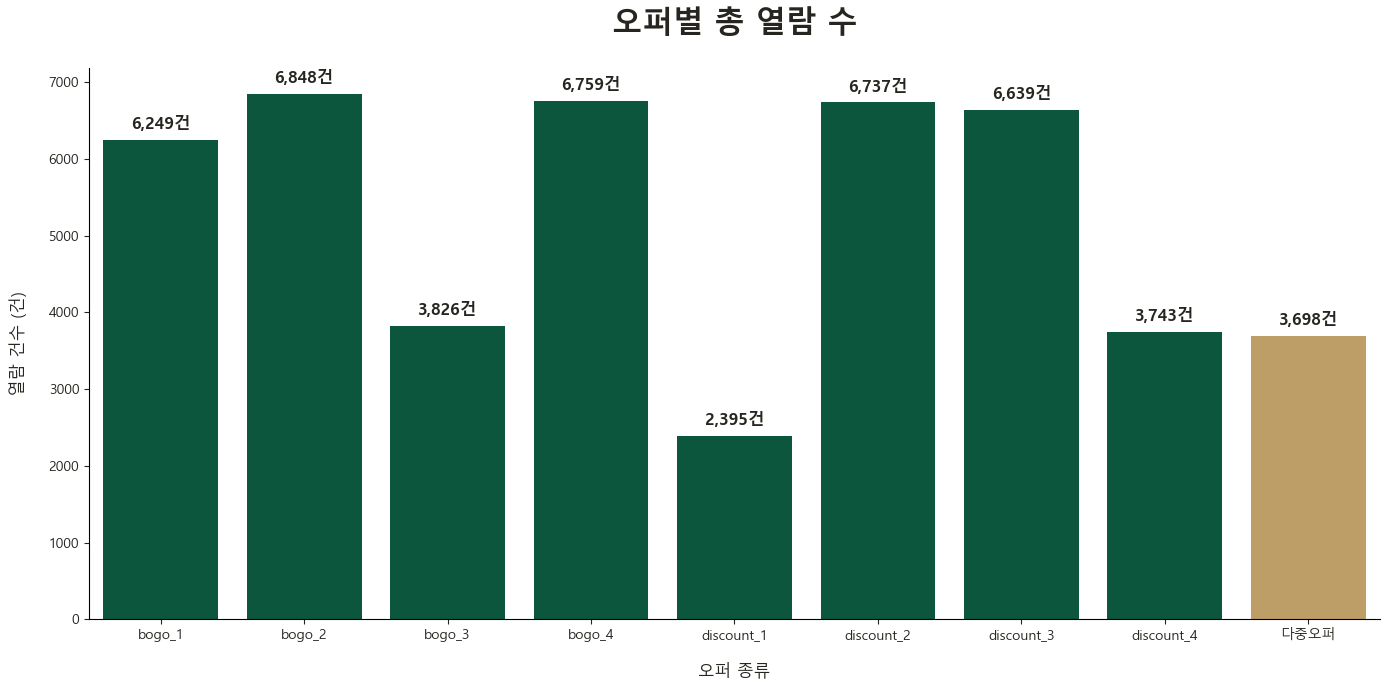

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 스타벅스 테마 컬러 세팅
SB_GREEN = '#006241'
SB_GOLD  = '#CBA258'
SB_BLACK = '#27251F'

plt.rcParams.update({'font.family': 'Malgun Gothic', 'axes.unicode_minus': False})

plt.figure(figsize=(14, 7))

# funnel_df의 인덱스('final_label')를 컬럼으로 꺼내서 사용합니다.
plot_data = funnel_df.reset_index()

# 카테고리별 색상 배정 
colors = [SB_GOLD if cat == '다중오퍼' else SB_GREEN for cat in plot_data['final_label']]

# 막대그래프 그리기 
ax = sns.barplot(data=plot_data, x='final_label', y='총열람수', palette=colors)

# 제목 및 라벨
plt.title('오퍼별 총 열람 수', fontsize=22, fontweight='bold', pad=25)
plt.xlabel('오퍼 종류', fontsize=12, labelpad=15)
plt.ylabel('열람 건수 (건)', fontsize=12, labelpad=15)

# 막대 위에 숫자 달아주기
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}건", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', xytext=(0, 5), 
                textcoords='offset points', fontsize=12, fontweight='bold', color=SB_BLACK)

plt.tight_layout()
plt.show()

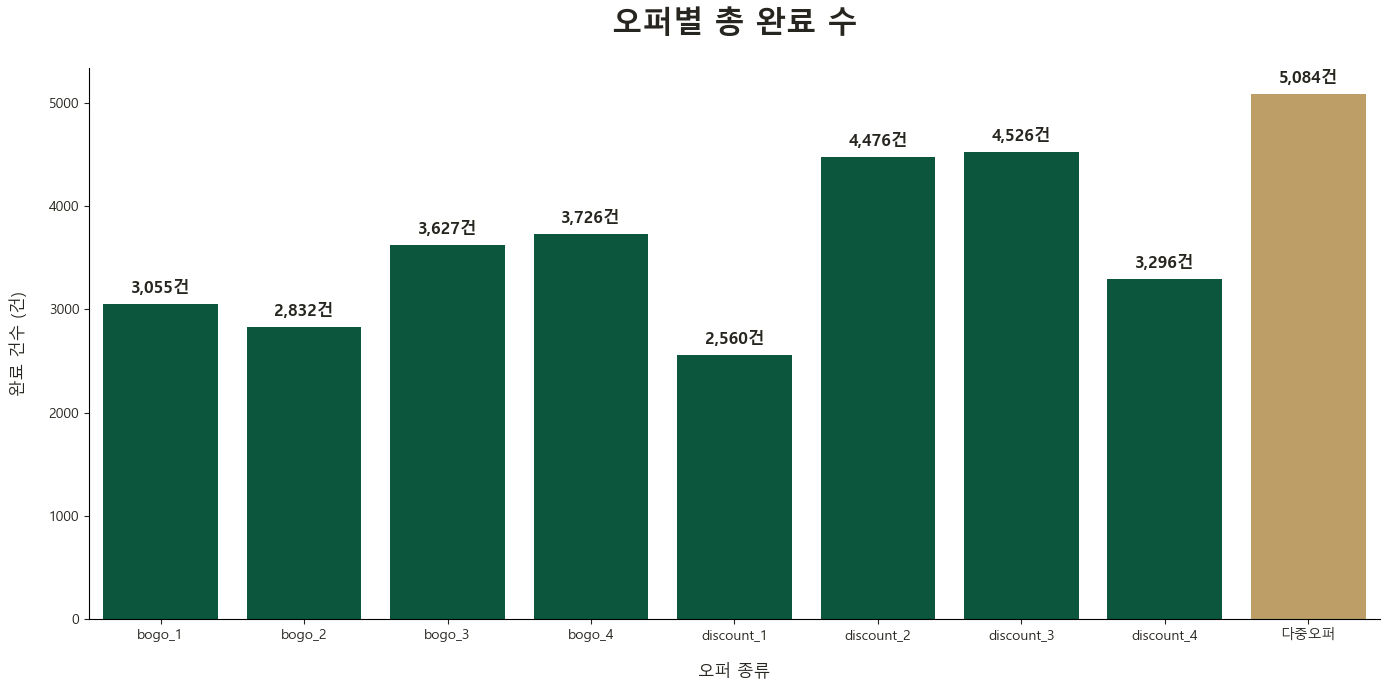

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 스타벅스 테마 컬러 세팅
SB_GREEN = '#006241'
SB_GOLD  = '#CBA258'
SB_BLACK = '#27251F'

plt.rcParams.update({'font.family': 'Malgun Gothic', 'axes.unicode_minus': False})

plt.figure(figsize=(14, 7))

# funnel_df의 인덱스('final_label')를 컬럼으로 꺼내서 사용합니다.
plot_data = funnel_df.reset_index()

# 카테고리별 색상 배정 
colors = [SB_GOLD if cat == '다중오퍼' else SB_GREEN for cat in plot_data['final_label']]

# 막대그래프 그리기 
ax = sns.barplot(data=plot_data, x='final_label', y='총완료수', palette=colors)

# 제목 및 라벨
plt.title('오퍼별 총 완료 수', fontsize=22, fontweight='bold', pad=25)
plt.xlabel('오퍼 종류', fontsize=12, labelpad=15)
plt.ylabel('완료 건수 (건)', fontsize=12, labelpad=15)

# 막대 위에 숫자 달아주기
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}건", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', xytext=(0, 5), 
                textcoords='offset points', fontsize=12, fontweight='bold', color=SB_BLACK)

plt.tight_layout()
plt.show()

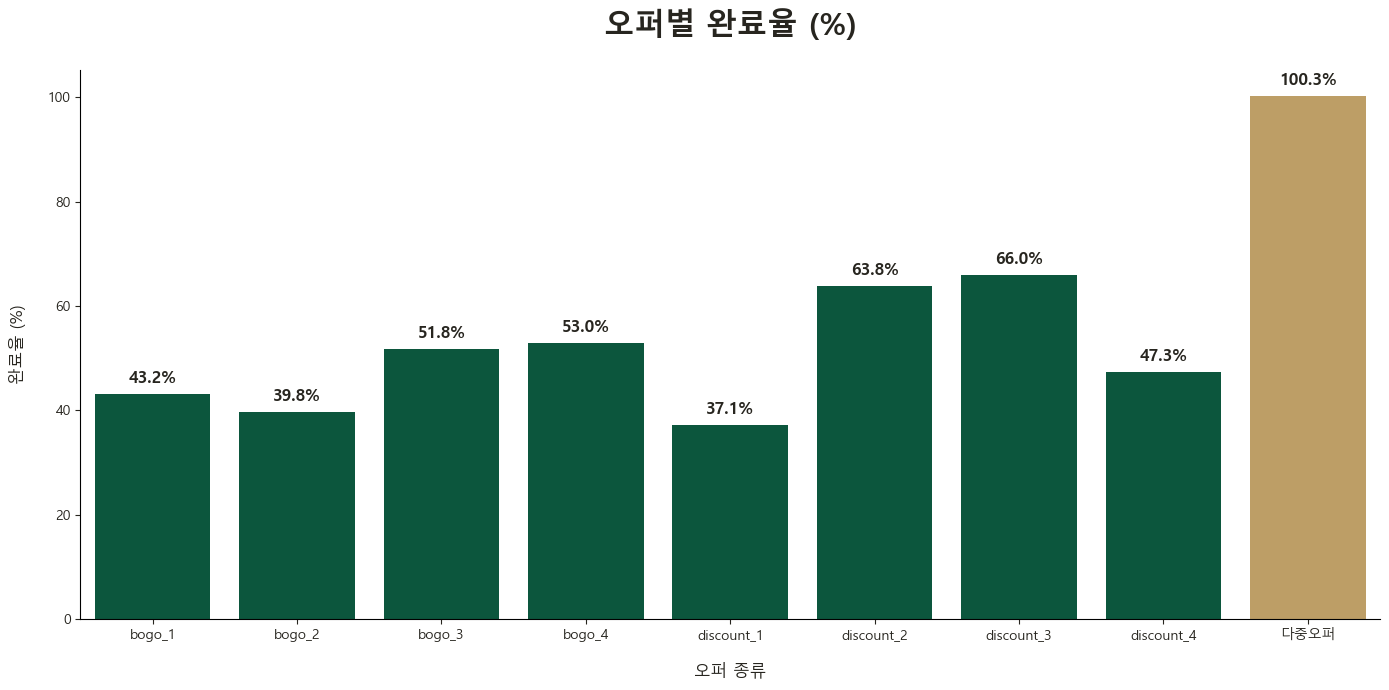

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 스타벅스 테마 컬러 세팅
SB_GREEN = '#006241'
SB_GOLD  = '#CBA258'
SB_BLACK = '#27251F'

plt.rcParams.update({'font.family': 'Malgun Gothic', 'axes.unicode_minus': False})

# 완료율 계산: (총완료수 / 총발송수) * 100
funnel_df['완료율(%)'] = (funnel_df['총완료수'] / funnel_df['총발송수']) * 100

plt.figure(figsize=(14, 7))

# funnel_df의 인덱스('final_label')를 컬럼으로 꺼내서 사용합니다.
plot_data = funnel_df.reset_index()

# 카테고리별 색상 배정 
colors = [SB_GOLD if cat == '다중오퍼' else SB_GREEN for cat in plot_data['final_label']]

# 막대그래프 그리기
ax = sns.barplot(data=plot_data, x='final_label', y='완료율(%)', palette=colors)

# 제목 및 라벨
plt.title('오퍼별 완료율 (%)', fontsize=22, fontweight='bold', pad=25)
plt.xlabel('오퍼 종류', fontsize=12, labelpad=15)
plt.ylabel('완료율 (%)', fontsize=12, labelpad=15)

# 막대 위에 소수점 첫째 자리와 % 기호 달아주기
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', xytext=(0, 5), 
                textcoords='offset points', fontsize=12, fontweight='bold', color=SB_BLACK)

plt.tight_layout()
plt.show()

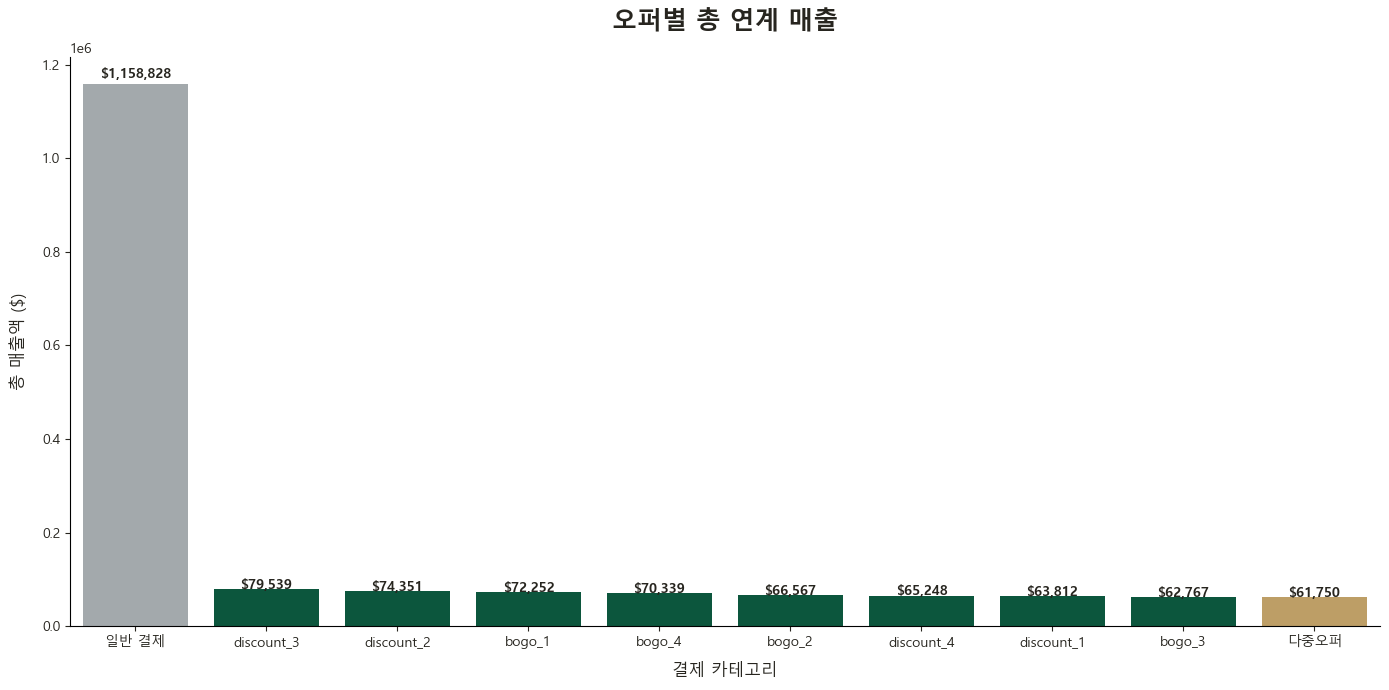

,final_label,amount
0,일반 결제,1158828.29
1,discount_3,79538.92
2,discount_2,74350.56
3,bogo_1,72251.56
4,bogo_4,70338.90
5,bogo_2,66567.32
6,discount_4,65247.52
7,discount_1,63811.75
8,bogo_3,62767.30
9,다중오퍼,61749.85


In [13]:
# 1. 일반 결제 금액 산출 (전체 - 오퍼)

# 전체 매출액 (merge_df 기준)
total_sales_val = merge_df[merge_df['event'] == 'transaction']['amount'].sum()

# 오퍼 연계 매출액 (trans_df에서 '일반'을 제외한 모든 것)
offer_sales_val = trans_df[~trans_df['final_label'].str.contains('일반', na=False)]['amount'].sum()

# 일반 결제액
normal_sales_val = total_sales_val - offer_sales_val

# 2. 시각화용 요약 테이블 만들기

# 1) 먼저 오퍼별 매출 집계
revenue_summary = trans_df[~trans_df['final_label'].str.contains('일반', na=False)].groupby('final_label')['amount'].sum().reset_index()

# 2) 여기에 계산한 '일반 결제' 행을 추가
normal_row = pd.DataFrame({'final_label': ['일반 결제'], 'amount': [normal_sales_val]})
revenue_summary = pd.concat([revenue_summary, normal_row], ignore_index=True)

# 3) 금액순으로 내림차순 정렬
revenue_summary = revenue_summary.sort_values(by='amount', ascending=False).reset_index(drop=True)

# 3. 시각화 (스타벅스 테마 적용)

SB_GREEN = '#006241'
SB_GOLD  = '#CBA258'
SB_GREY  = '#A2AAAD'
SB_BLACK = '#27251F'

plt.rcParams.update({
    'font.family': 'Malgun Gothic', # 맥북은 'AppleGothic'
    'axes.unicode_minus': False,
    'text.color': SB_BLACK,
    'axes.labelcolor': SB_BLACK,
})

plt.figure(figsize=(14, 7))

# 카테고리에 따른 색상 배정 (일반: 회색, 다중오퍼: 골드, 개별오퍼: 그린)
def set_color(cat):
    if cat == '일반 결제': return SB_GREY
    elif cat == '다중오퍼': return SB_GOLD
    else: return SB_GREEN

colors = [set_color(cat) for cat in revenue_summary['final_label']]

# 막대그래프 그리기
ax = sns.barplot(data=revenue_summary, x='final_label', y='amount', palette=colors)

plt.title('오퍼별 총 연계 매출', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('결제 카테고리', fontsize=12, labelpad=10)
plt.ylabel('총 매출액 ($)', fontsize=12, labelpad=10)

# 막대 위에 금액 표시 (천 단위 콤마 + $)
for i, v in enumerate(revenue_summary['amount']):
    ax.text(i, v + (v * 0.01), f"${v:,.0f}", ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# 데이터 확인
display(revenue_summary)

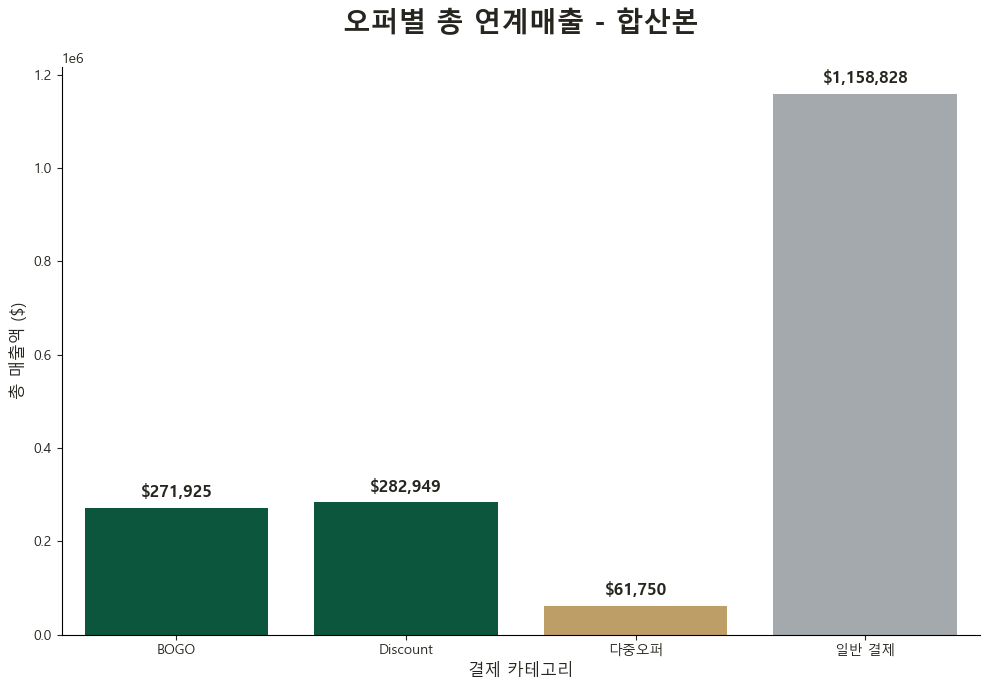

,group,amount
0,BOGO,271925.08
1,Discount,282948.75
2,다중오퍼,61749.85
3,일반 결제,1158828.29


In [14]:

# 1.  그룹화 데이터 준비
# 아까 만든 10종 매출 데이터(total_rev_10)를 활용
summary_4 = total_rev_10.copy()

def get_group_4(label):
    if 'bogo' in label.lower(): return 'BOGO'
    elif 'discount' in label.lower(): return 'Discount'
    elif '다중' in label: return '다중오퍼'
    else: return '일반 결제'

summary_4['group'] = summary_4['final_label'].apply(get_group_4)

# 그룹별 매출 합계 계산
summary_4_final = summary_4.groupby('group')['amount'].sum().reset_index()

# 순서 고정
order_4 = ['BOGO', 'Discount', '다중오퍼', '일반 결제']
summary_4_final['group'] = pd.Categorical(summary_4_final['group'], categories=order_4, ordered=True)
summary_4_final = summary_4_final.sort_values('group')


# 2. 시각화 (스타벅스 테마)
SB_GREEN = '#006241'
SB_GOLD  = '#CBA258'
SB_GREY  = '#A2AAAD'
SB_BLACK = '#27251F'

plt.figure(figsize=(10, 7))

# 색상 매칭
colors_4 = [SB_GREEN, SB_GREEN, SB_GOLD, SB_GREY]

ax = sns.barplot(data=summary_4_final, x='group', y='amount', palette=colors_4)

plt.title('오퍼별 총 연계매출 - 합산본', fontsize=20, fontweight='bold', pad=25)
plt.xlabel('결제 카테고리', fontsize=12)
plt.ylabel('총 매출액 ($)', fontsize=12)

# 금액 표시 ($ + 천 단위 콤마)
for p in ax.patches:
    val = p.get_height()
    ax.annotate(f"${val:,.0f}", 
                (p.get_x() + p.get_width() / 2., val), 
                ha='center', va='bottom', xytext=(0, 5), 
                textcoords='offset points', fontsize=12, fontweight='bold', color=SB_BLACK)

plt.tight_layout()
plt.show()

# 데이터 요약 표 출력
display(summary_4_final)

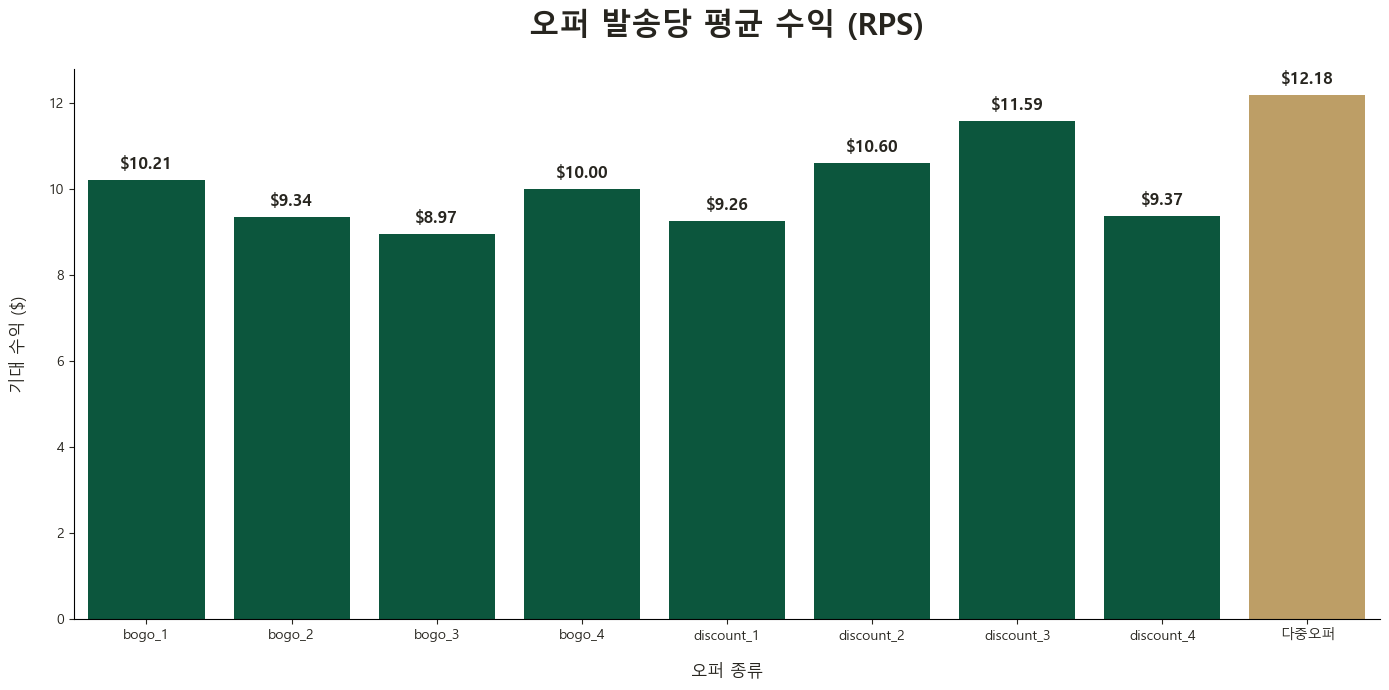

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 오퍼 연계 결제만 필터링
offer_txns = trans_df[trans_df['final_label'] != '일반결제']

# 효율 지표 계산 (총매출, 거래횟수, 인원수)
efficiency_df = pd.DataFrame({
    '총매출': offer_txns.groupby('final_label')['amount'].sum(),
    '결제인원수': offer_txns.groupby('final_label')['person'].nunique()
})

# RPS(발송당 기대수익) 계산 - funnel_df의 총발송수와 매칭
efficiency_df['발송1건당_매출'] = efficiency_df['총매출'] / funnel_df['총발송수']

# 순서 정렬 (bogo_1 ~ 다중오퍼)
order = ['bogo_1', 'bogo_2', 'bogo_3', 'bogo_4', 'discount_1', 'discount_2', 'discount_3', 'discount_4', '다중오퍼']
efficiency_df = efficiency_df.reindex(order)

# 그래프용 데이터 변환 
plot_data = efficiency_df.reset_index()

# 2. 시각화 

SB_GREEN = '#006241'
SB_GOLD  = '#CBA258'
SB_BLACK = '#27251F'

plt.rcParams.update({'font.family': 'Malgun Gothic', 'axes.unicode_minus': False})
plt.figure(figsize=(14, 7))

colors = [SB_GOLD if cat == '다중오퍼' else SB_GREEN for cat in plot_data['final_label']]

# 그래프 그리기
ax = sns.barplot(data=plot_data, x='final_label', y='발송1건당_매출', palette=colors)


plt.title('오퍼 발송당 평균 수익 (RPS)', fontsize=22, fontweight='bold', pad=25)
plt.xlabel('오퍼 종류', fontsize=12, labelpad=15)
plt.ylabel('기대 수익 ($)', fontsize=12, labelpad=15)

# 값 표시 
for p in ax.patches:
    val = p.get_height()
    if pd.notnull(val): # 데이터가 있는 경우만 표시
        ax.annotate(f"${val:.2f}", 
                    (p.get_x() + p.get_width() / 2., val), 
                    ha='center', va='bottom', xytext=(0, 5), 
                    textcoords='offset points', fontsize=12, fontweight='bold', color=SB_BLACK)

plt.tight_layout()
plt.show()

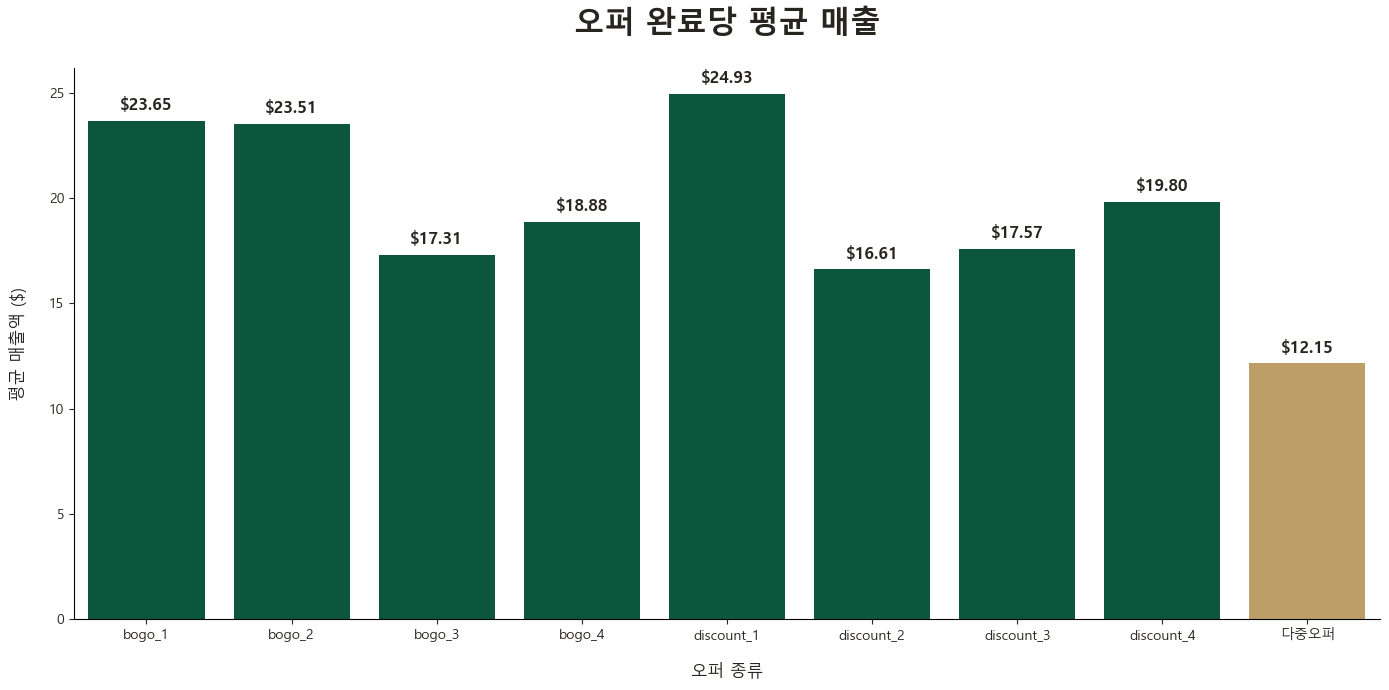

,총매출,완료당_평균_매출
final_label,,
bogo_1,72251.56,23.650265
bogo_2,66567.32,23.505410
bogo_3,62767.30,17.305569
bogo_4,70338.90,18.877858
discount_1,63811.75,24.926465
discount_2,74350.56,16.610938
discount_3,79538.92,17.573778
discount_4,65247.52,19.795971
다중오퍼,61749.85,12.145919


In [16]:
# 1. 데이터 계산 (완료당 매출)

# efficiency_df에 '완료당_평균_매출' 컬럼 추가
# 총매출을 funnel_df의 총완료수로 나눔
efficiency_df['완료당_평균_매출'] = efficiency_df['총매출'] / funnel_df['총완료수']

# 그래프용 데이터 변환 
plot_data_comp = efficiency_df.reset_index()

# 2. 시각화 (스타벅스 테마)

SB_GREEN = '#006241'
SB_GOLD  = '#CBA258'
SB_BLACK = '#27251F'

plt.rcParams.update({'font.family': 'Malgun Gothic', 'axes.unicode_minus': False})
plt.figure(figsize=(14, 7))

# 색상 설정 
colors = [SB_GOLD if cat == '다중오퍼' else SB_GREEN for cat in plot_data_comp['final_label']]

# 막대그래프 그리기
ax = sns.barplot(data=plot_data_comp, x='final_label', y='완료당_평균_매출', palette=colors)

plt.title('오퍼 완료당 평균 매출', fontsize=22, fontweight='bold', pad=25)
plt.xlabel('오퍼 종류', fontsize=12, labelpad=15)
plt.ylabel('평균 매출액 ($)', fontsize=12, labelpad=15)

# 막대 위에 금액 표시 ($ + 소수점 둘째자리)
for p in ax.patches:
    val = p.get_height()
    if pd.notnull(val):
        ax.annotate(f"${val:.2f}", 
                    (p.get_x() + p.get_width() / 2., val), 
                    ha='center', va='bottom', xytext=(0, 5), 
                    textcoords='offset points', fontsize=12, fontweight='bold', color=SB_BLACK)

plt.tight_layout()
plt.show()

# 데이터 확인용
display(efficiency_df[['총매출', '완료당_평균_매출']].head(10))

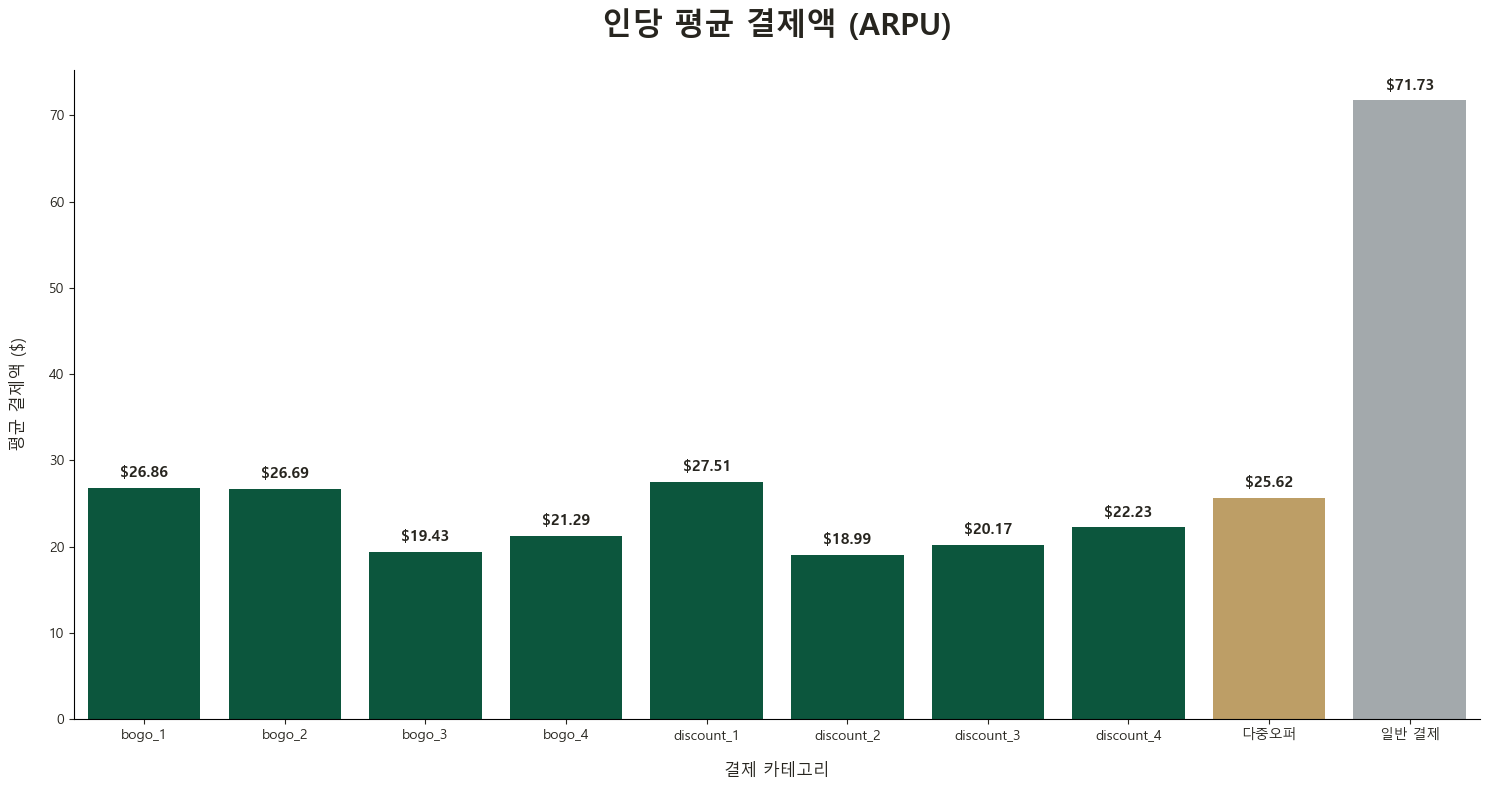

,final_label,총매출,결제인원수,ARPU
0,bogo_1,72251.56,2690,26.859316
1,bogo_2,66567.32,2494,26.690986
2,bogo_3,62767.30,3230,19.432601
3,bogo_4,70338.90,3304,21.289013
4,discount_1,63811.75,2320,27.505065
5,discount_2,74350.56,3915,18.991203
6,discount_3,79538.92,3944,20.167069
7,discount_4,65247.52,2935,22.230842
8,다중오퍼,61749.85,2410,25.622344
9,일반 결제,1158828.29,16156,71.727426


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. ARPU 데이터 계산 (인원수 기준)
# trans_df의 final_label 이름을 통일 (띄어쓰기 방지)
trans_df['final_label'] = trans_df['final_label'].replace('일반결제', '일반 결제')

# 카테고리별 총매출액과 순수 결제 인원수(Unique Users) 계산
arpu_df = trans_df.groupby('final_label').agg({
    'amount': 'sum',
    'person': 'nunique'
}).reset_index()

# 컬럼 이름 변경 및 ARPU 계산
arpu_df.columns = ['final_label', '총매출', '결제인원수']
arpu_df['ARPU'] = arpu_df['총매출'] / arpu_df['결제인원수']

# 10개 카테고리 순서 정의
order_10 = [
    'bogo_1', 'bogo_2', 'bogo_3', 'bogo_4', 
    'discount_1', 'discount_2', 'discount_3', 'discount_4', 
    '다중오퍼', '일반 결제'
]

arpu_df['final_label'] = pd.Categorical(arpu_df['final_label'], categories=order_10, ordered=True)
arpu_df = arpu_df.sort_values('final_label')


# 2. 시각화 (스타벅스 테마)
SB_GREEN = '#006241'
SB_GOLD  = '#CBA258'
SB_GREY  = '#A2AAAD'
SB_BLACK = '#27251F'

plt.rcParams.update({'font.family': 'Malgun Gothic', 'axes.unicode_minus': False})
plt.figure(figsize=(15, 8))

# 색상 설정 
colors = [SB_GREY if cat == '일반 결제' else (SB_GOLD if cat == '다중오퍼' else SB_GREEN) for cat in arpu_df['final_label']]

# 막대그래프 그리기
ax = sns.barplot(data=arpu_df, x='final_label', y='ARPU', palette=colors)


plt.title('인당 평균 결제액 (ARPU)', fontsize=22, fontweight='bold', pad=25)
plt.xlabel('결제 카테고리', fontsize=12, labelpad=15)
plt.ylabel('평균 결제액 ($)', fontsize=12, labelpad=15)

# 막대 위에 금액 표시 
for p in ax.patches:
    val = p.get_height()
    ax.annotate(f"${val:.2f}", 
                (p.get_x() + p.get_width() / 2., val), 
                ha='center', va='bottom', xytext=(0, 5), 
                textcoords='offset points', fontsize=11, fontweight='bold', color=SB_BLACK)

plt.tight_layout()
plt.show()

# 데이터 요약 표 출력
display(arpu_df[['final_label', '총매출', '결제인원수', 'ARPU']])

2. 채널별8종

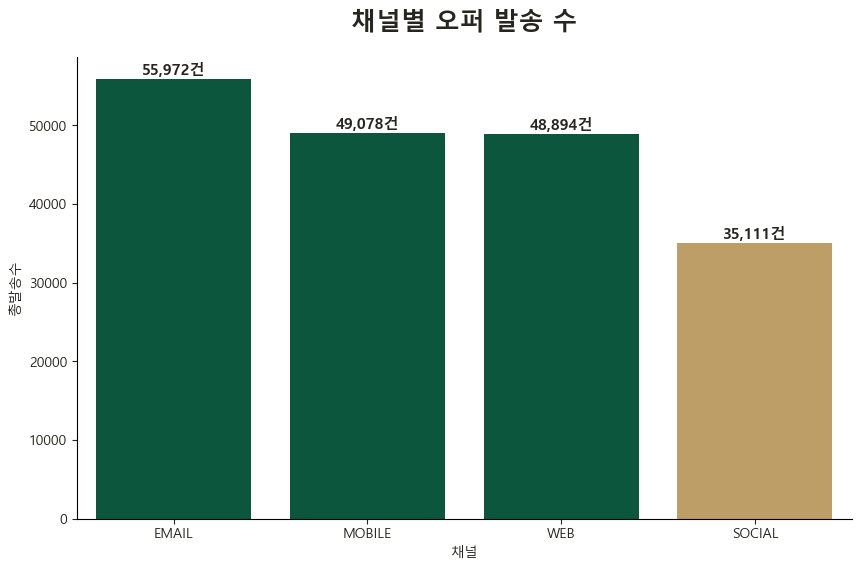

In [18]:

#  채널별 총 발송 수 (Received)

# 8종 개별 오퍼만 대상 (다중오퍼/일반결제 제외하고 진짜 채널 효과만 보기!)
offer_8_labels = ['bogo_1', 'bogo_2', 'bogo_3', 'bogo_4', 'discount_1', 'discount_2', 'discount_3', 'discount_4']
channel_base = master_df[(master_df['final_label'].isin(offer_8_labels)) & (master_df['event'] == 'received')]

# 채널별 컬럼 합계 구하기
channels = ['web', 'email', 'mobile', 'social']
channel_sent = channel_base[channels].sum().reset_index()
channel_sent.columns = ['채널', '총발송수']
channel_sent['채널'] = channel_sent['채널'].str.upper()

# --- 시각화 ---
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=channel_sent.sort_values('총발송수', ascending=False), 
                 x='채널', y='총발송수', palette=[SB_GREEN, SB_GREEN, SB_GREEN, SB_GOLD]) 

plt.title('채널별 오퍼 발송 수', fontsize=18, fontweight='bold', pad=20)

for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}건", (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.show()

앞선 세개와 다르게 social 채널은 8종 오퍼 중 4종만 포함

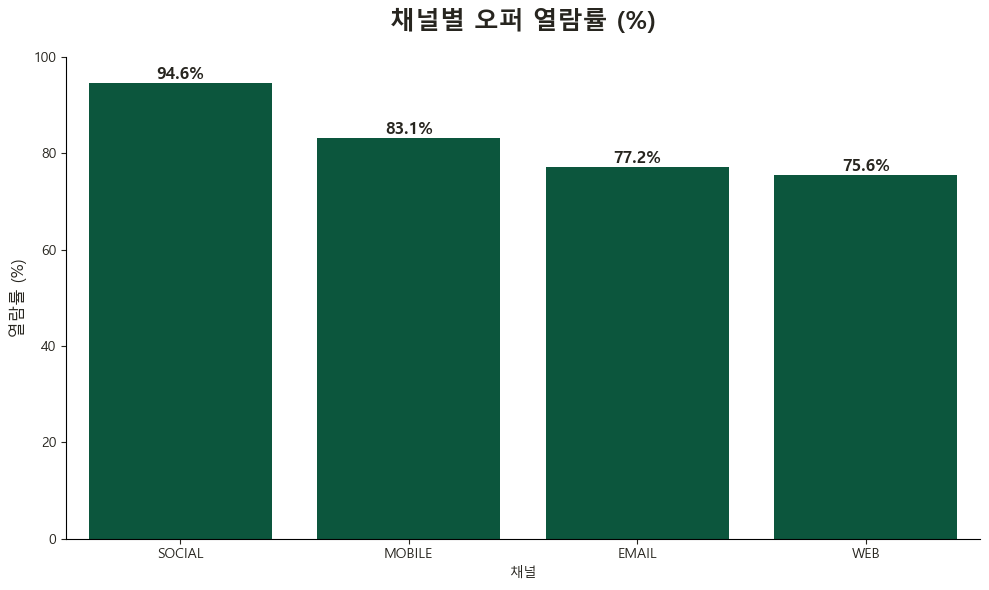

In [19]:

# 채널별 열람률 계산 (Viewed / Received)

# 8종 개별 오퍼만 필터링
offer_8_labels = ['bogo_1', 'bogo_2', 'bogo_3', 'bogo_4', 'discount_1', 'discount_2', 'discount_3', 'discount_4']
offer_8_df = master_df[master_df['final_label'].isin(offer_8_labels)]

channels = ['web', 'email', 'mobile', 'social']

# 채널별 발송 수(received)와 열람 수(viewed) 집계
sent_by_channel = offer_8_df[offer_8_df['event'] == 'received'][channels].sum()
viewed_by_channel = offer_8_df[offer_8_df['event'] == 'viewed'][channels].sum()

# 열람률(%) 계산
channel_view_rate = (viewed_by_channel / sent_by_channel * 100).reset_index()
channel_view_rate.columns = ['채널', '열람률']
channel_view_rate['채널'] = channel_view_rate['채널'].str.upper()


# 2. 시각화

SB_GREEN = '#006241'
SB_BLACK = '#27251F'

plt.figure(figsize=(10, 6))

ax = sns.barplot(data=channel_view_rate.sort_values('열람률', ascending=False), 
                 x='채널', y='열람률', color=SB_GREEN)

plt.title('채널별 오퍼 열람률 (%)', fontsize=18, fontweight='bold', pad=20)
plt.ylabel('열람률 (%)', fontsize=12)

# 막대 위에 퍼센트(%) 표시
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12, fontweight='bold', color=SB_BLACK)

plt.ylim(0, 100) 
plt.tight_layout()
plt.show()

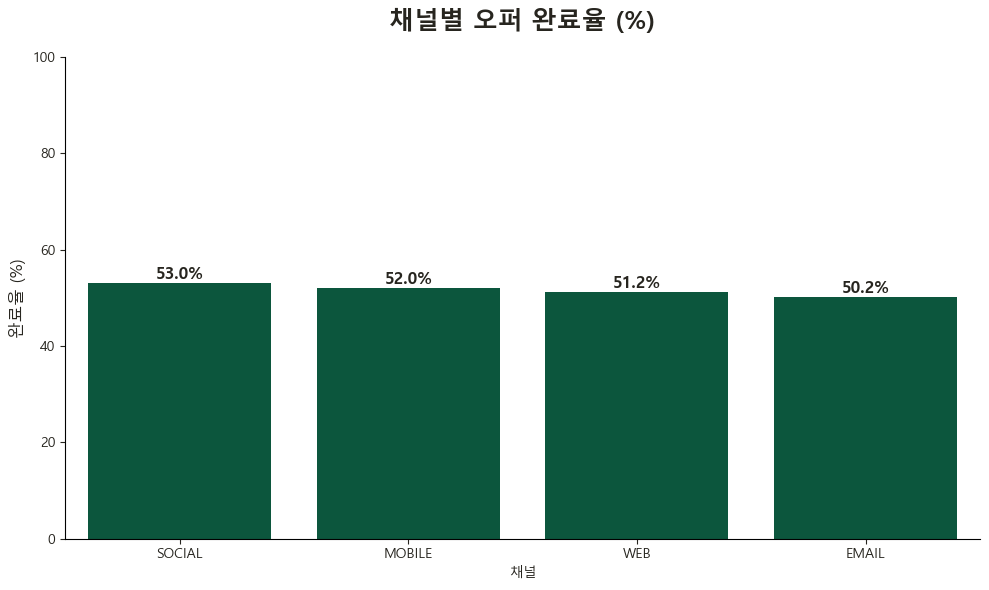

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 채널별 완료율 계산 (Completed / Received)

# 8종 개별 오퍼만 필터링
offer_8_labels = ['bogo_1', 'bogo_2', 'bogo_3', 'bogo_4', 'discount_1', 'discount_2', 'discount_3', 'discount_4']
offer_8_df = master_df[master_df['final_label'].isin(offer_8_labels)]

channels = ['web', 'email', 'mobile', 'social']

# 채널별 발송 수(received)와 완료 수(completed) 집계
sent_by_channel = offer_8_df[offer_8_df['event'] == 'received'][channels].sum()
completed_by_channel = offer_8_df[offer_8_df['event'] == 'completed'][channels].sum()

# 완료율(%) 계산: (총완료수 / 총발송수) * 100
channel_complete_rate = (completed_by_channel / sent_by_channel * 100).reset_index()
channel_complete_rate.columns = ['채널', '완료율']
channel_complete_rate['채널'] = channel_complete_rate['채널'].str.upper()

# 2. 시각화 
SB_GREEN = '#006241'
SB_BLACK = '#27251F'

plt.figure(figsize=(10, 6))

ax = sns.barplot(data=channel_complete_rate.sort_values('완료율', ascending=False), 
                 x='채널', y='완료율', color=SB_GREEN)

plt.title('채널별 오퍼 완료율 (%)', fontsize=18, fontweight='bold', pad=20)
plt.ylabel('완료율 (%)', fontsize=12)

# 막대 위에 퍼센트(%) 표시
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12, fontweight='bold', color=SB_BLACK)

plt.ylim(0, 100) 
plt.tight_layout()
plt.show()

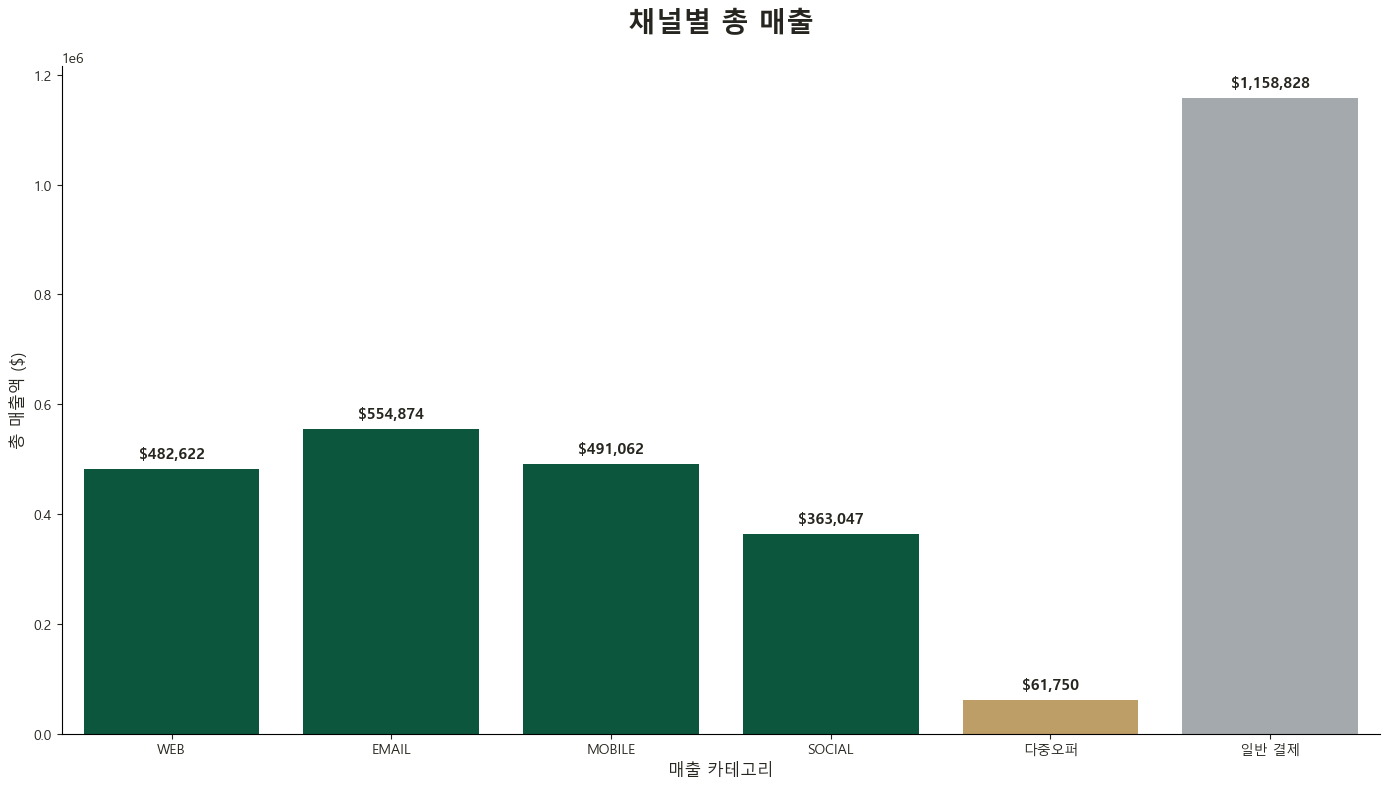

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 채널별 매출 집계
# 8종 오퍼 이름표 정의
offer_8_labels = ['bogo_1', 'bogo_2', 'bogo_3', 'bogo_4', 'discount_1', 'discount_2', 'discount_3', 'discount_4']

# 오퍼별 매출액 집계
rev_by_offer = trans_df.groupby('final_label')['amount'].sum().reset_index()

# master_df에서 오퍼별 채널 매핑 정보 추출
channels = ['web', 'email', 'mobile', 'social']
offer_channel_map = master_df[master_df['offer_label'].isin(offer_8_labels)][['offer_label'] + channels].drop_duplicates()

# 4대 채널 매출액 계산
channel_total_rev = []
for ch in channels:
    # 해당 채널을 포함하는 오퍼들 찾기
    linked_offers = offer_channel_map[offer_channel_map[ch] == 1]['offer_label'].tolist()
    # 해당 오퍼들의 매출 합산
    ch_sum = rev_by_offer[rev_by_offer['final_label'].isin(linked_offers)]['amount'].sum()
    channel_total_rev.append({'category': ch.upper(), 'amount': ch_sum})

# 2. 다중오퍼 및 일반 결제 추가
# 다중오퍼 매출
multi_rev_val = rev_by_offer[rev_by_offer['final_label'] == '다중오퍼']['amount'].sum()

# 일반 결제 매출 (전체 - 오퍼연계) 로직 재확인
total_sales_val = merge_df[merge_df['event'] == 'transaction']['amount'].sum()
offer_sales_val = trans_df[~trans_df['final_label'].str.contains('일반', na=False)]['amount'].sum()
normal_rev_val = total_sales_val - offer_sales_val

# 리스트에 추가
channel_total_rev.append({'category': '다중오퍼', 'amount': multi_rev_val})
channel_total_rev.append({'category': '일반 결제', 'amount': normal_rev_val})

# 데이터프레임 변환
df_final_revenue = pd.DataFrame(channel_total_rev)

# 3. 시각화 
SB_GREEN = '#006241'
SB_GOLD  = '#CBA258'
SB_GREY  = '#A2AAAD'
SB_BLACK = '#27251F'

plt.figure(figsize=(14, 8))

# 색상 설정: 채널(그린), 다중(골드), 일반(회색)
colors = [SB_GREEN, SB_GREEN, SB_GREEN, SB_GREEN, SB_GOLD, SB_GREY]

ax = sns.barplot(data=df_final_revenue, x='category', y='amount', palette=colors)

plt.title('채널별 총 매출', fontsize=20, fontweight='bold', pad=25)
plt.ylabel('총 매출액 ($)', fontsize=12)
plt.xlabel('매출 카테고리', fontsize=12)

# 막대 위에 금액 표시 ($ + 콤마)
for p in ax.patches:
    val = p.get_height()
    ax.annotate(f"${val:,.0f}", 
                (p.get_x() + p.get_width() / 2., val), 
                ha='center', va='bottom', xytext=(0, 5), 
                textcoords='offset points', fontsize=11, fontweight='bold', color=SB_BLACK)

plt.tight_layout()
plt.show()

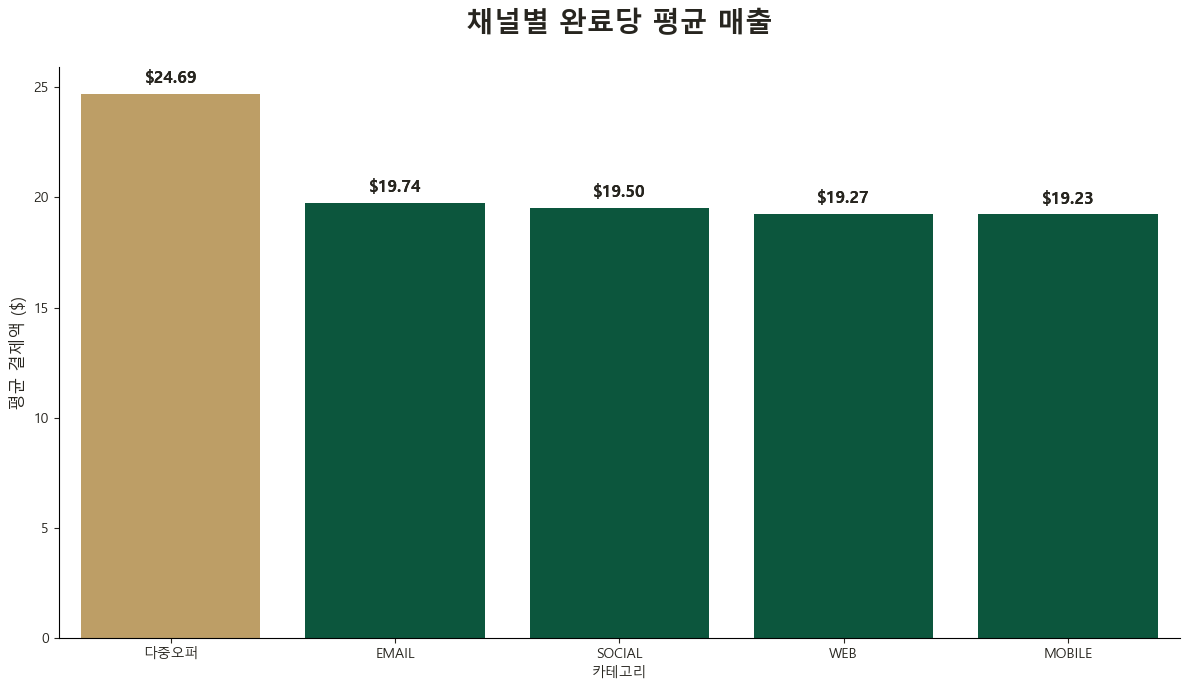

In [22]:
# 1. 채널별 & 다중오퍼 완료당 매출 계산

# 8종 개별 오퍼 리스트
offer_8_labels = ['bogo_1', 'bogo_2', 'bogo_3', 'bogo_4', 'discount_1', 'discount_2', 'discount_3', 'discount_4']

# 채널 데이터 집계
channels = ['web', 'email', 'mobile', 'social']
channel_data = []

for ch in channels:
    # 해당 채널을 포함하는 8종 오퍼의 완료(completed) 건들
    ch_comps = master_df[(master_df['event'] == 'completed') & 
                         (master_df['final_label'].isin(offer_8_labels)) & 
                         (master_df[ch] == 1)]
    
    # 해당 완료 건의 총 매출액 매칭
    ch_rev = pd.merge(ch_comps[['person', 'time']], 
                      trans_df[['person', 'time', 'amount']], 
                      on=['person', 'time'], how='inner')['amount'].sum()
    
    ch_count = len(ch_comps)
    avg_val = ch_rev / ch_count if ch_count > 0 else 0
    channel_data.append({'카테고리': ch.upper(), '완료당_평균_매출': avg_val})

# 다중오퍼 데이터 집계
multi_comps = master_df[(master_df['event'] == 'completed') & (master_df['final_label'] == '다중오퍼')]
multi_rev = pd.merge(multi_comps[['person', 'time']], 
                     trans_df[['person', 'time', 'amount']], 
                     on=['person', 'time'], how='inner')['amount'].sum()
multi_count = len(multi_comps)
multi_avg = multi_rev / multi_count if multi_count > 0 else 0

# 데이터 합치기
df_comp_final = pd.DataFrame(channel_data)
df_comp_final = pd.concat([df_comp_final, pd.DataFrame([{'카테고리': '다중오퍼', '완료당_평균_매출': multi_avg}])], ignore_index=True)

# 2. 시각화 

SB_GREEN = '#006241'
SB_GOLD  = '#CBA258'
SB_BLACK = '#27251F'

plt.figure(figsize=(12, 7))

# 색상 설정
colors = [SB_GREEN] * 4 + [SB_GOLD]

# 금액 순으로 정렬
ax = sns.barplot(data=df_comp_final.sort_values('완료당_평균_매출', ascending=False), 
                 x='카테고리', y='완료당_평균_매출', palette='viridis') # 혹은 위에서 만든 colors 적용

# 직접 지정한 색상 적용 (정렬 상태에 맞게 다시 매핑)
plot_order = df_comp_final.sort_values('완료당_평균_매출', ascending=False)['카테고리'].tolist()
final_colors = [SB_GOLD if cat == '다중오퍼' else SB_GREEN for cat in plot_order]

ax = sns.barplot(data=df_comp_final.sort_values('완료당_평균_매출', ascending=False), 
                 x='카테고리', y='완료당_평균_매출', palette=final_colors)

plt.title('채널별 완료당 평균 매출', fontsize=20, fontweight='bold', pad=25)
plt.ylabel('평균 결제액 ($)', fontsize=12)

# 막대 위에 금액 표시
for p in ax.patches:
    val = p.get_height()
    ax.annotate(f"${val:.2f}", 
                (p.get_x() + p.get_width() / 2., val), 
                ha='center', va='bottom', xytext=(0, 5), 
                textcoords='offset points', fontsize=12, fontweight='bold', color=SB_BLACK)

plt.tight_layout()
plt.show()

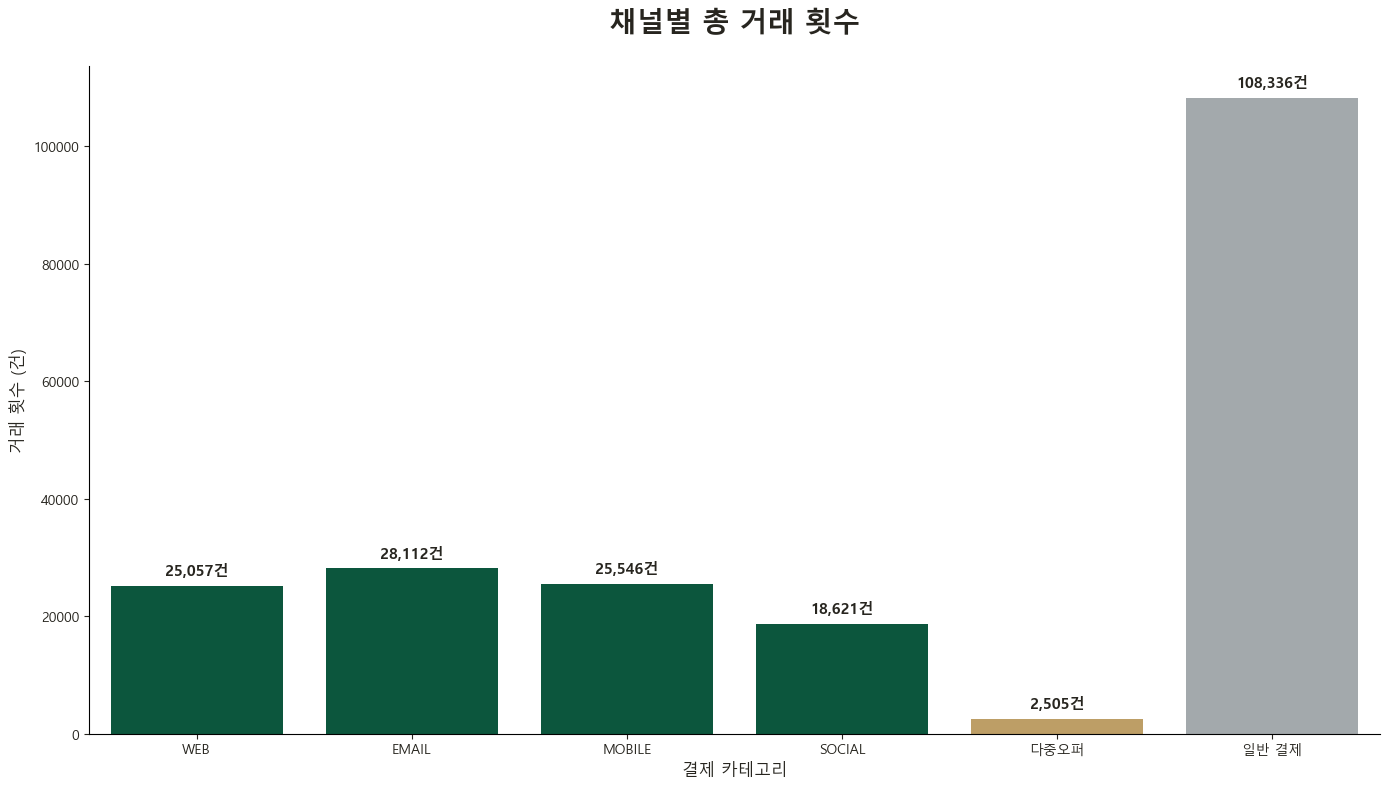

In [23]:
# 1. 거래 횟수 집계 

# 8종 오퍼 리스트
offer_8_labels = ['bogo_1', 'bogo_2', 'bogo_3', 'bogo_4', 'discount_1', 'discount_2', 'discount_3', 'discount_4']

# 오퍼별 거래 횟수 계산 (trans_df 활용)
counts_by_offer = trans_df.groupby('final_label').size().reset_index(name='count')

# 4대 채널 거래 횟수 (8종 오퍼 매핑)
channels = ['web', 'email', 'mobile', 'social']
offer_channel_map = master_df[master_df['offer_label'].isin(offer_8_labels)][['offer_label'] + channels].drop_duplicates()

channel_counts = []
for ch in channels:
    # 해당 채널을 포함하는 오퍼들 찾기
    linked_offers = offer_channel_map[offer_channel_map[ch] == 1]['offer_label'].tolist()
    # 해당 오퍼들의 거래 횟수 합산
    ch_sum = counts_by_offer[counts_by_offer['final_label'].isin(linked_offers)]['count'].sum()
    channel_counts.append({'category': ch.upper(), 'count': ch_sum})

# 다중오퍼 및 일반 결제 추가
# 다중오퍼 횟수
multi_count_val = counts_by_offer[counts_by_offer['final_label'] == '다중오퍼']['count'].sum()

# 일반 결제 횟수 (전체 거래수 - 오퍼연계 거래수)
total_txn_count = len(merge_df[merge_df['event'] == 'transaction'])
offer_txn_count = len(trans_df[~trans_df['final_label'].str.contains('일반', na=False)])
normal_count_val = total_txn_count - offer_txn_count

# 최종 데이터 정리
channel_counts.append({'category': '다중오퍼', 'count': multi_count_val})
channel_counts.append({'category': '일반 결제', 'count': normal_count_val})

df_final_counts = pd.DataFrame(channel_counts)


# 2. 시각화 

SB_GREEN = '#006241'
SB_GOLD  = '#CBA258'
SB_GREY  = '#A2AAAD'
SB_BLACK = '#27251F'

plt.figure(figsize=(14, 8))

# 색상
colors = [SB_GREEN, SB_GREEN, SB_GREEN, SB_GREEN, SB_GOLD, SB_GREY]

ax = sns.barplot(data=df_final_counts, x='category', y='count', palette=colors)

plt.title('채널별 총 거래 횟수', fontsize=20, fontweight='bold', pad=25)
plt.ylabel('거래 횟수 (건)', fontsize=12)
plt.xlabel('결제 카테고리', fontsize=12)

# 막대 위에 숫자 표시 (천 단위 콤마)
for p in ax.patches:
    val = p.get_height()
    ax.annotate(f"{int(val):,}건", 
                (p.get_x() + p.get_width() / 2., val), 
                ha='center', va='bottom', xytext=(0, 5), 
                textcoords='offset points', fontsize=11, fontweight='bold', color=SB_BLACK)

plt.tight_layout()
plt.show()

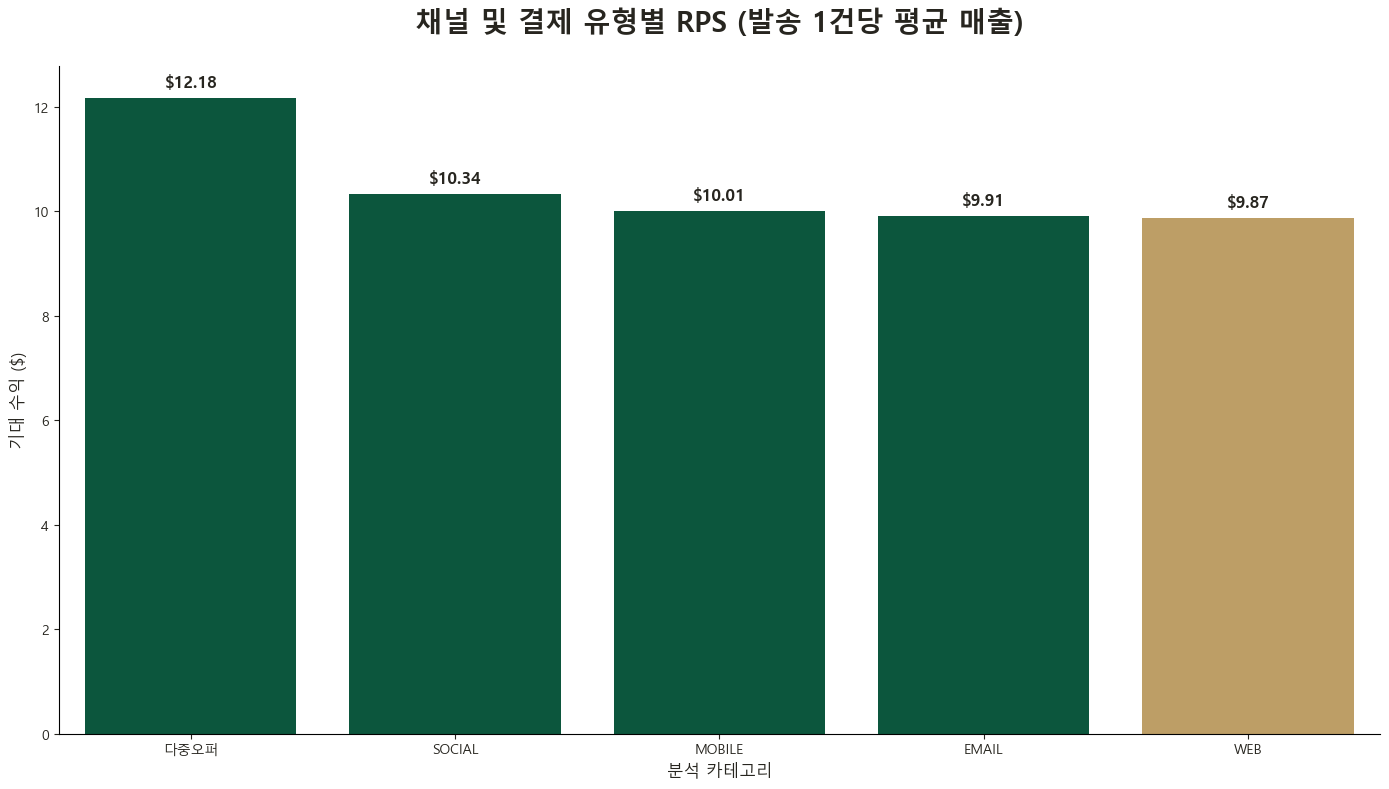

In [24]:
# 1. 카테고리별 RPS 계산 (Revenue / Sent)

# 8종 오퍼 리스트
offer_8_labels = ['bogo_1', 'bogo_2', 'bogo_3', 'bogo_4', 'discount_1', 'discount_2', 'discount_3', 'discount_4']

# 오퍼별 매출액 집계
rev_by_label = trans_df.groupby('final_label')['amount'].sum()

# 4대 채널 RPS 계산 (8종 오퍼 기준)
channels = ['web', 'email', 'mobile', 'social']
rps_6_data = []

for ch in channels:
    # 해당 채널을 포함하는 8종 오퍼의 발송(received) 건수
    ch_sent = master_df[(master_df['event'] == 'received') & 
                        (master_df['final_label'].isin(offer_8_labels)) & 
                        (master_df[ch] == 1)].shape[0]
    
    # 해당 채널을 포함하는 오퍼들의 총 매출액
    linked_offers = offer_channel_map[offer_channel_map[ch] == 1]['offer_label'].tolist()
    ch_rev = rev_by_label[rev_by_label.index.isin(linked_offers)].sum()
    
    # RPS 계산
    ch_rps = ch_rev / ch_sent if ch_sent > 0 else 0
    rps_6_data.append({'category': ch.upper(), 'RPS': ch_rps})

# 다중오퍼 RPS 추가
multi_sent = master_df[(master_df['event'] == 'received') & (master_df['final_label'] == '다중오퍼')].shape[0]
multi_rev = rev_by_label.get('다중오퍼', 0)
multi_rps = multi_rev / multi_sent if multi_sent > 0 else 0
rps_6_data.append({'category': '다중오퍼', 'RPS': multi_rps})

df_rps_6 = pd.DataFrame(rps_6_data)

# 2. 시각화 (스타벅스 테마)

SB_GREEN = '#006241'
SB_GOLD  = '#CBA258'
SB_GREY  = '#A2AAAD'
SB_BLACK = '#27251F'

plt.figure(figsize=(14, 8))

# 색상 설정 (채널: 그린, 다중: 골드, 일반: 회색)
colors = [SB_GREEN, SB_GREEN, SB_GREEN, SB_GREEN, SB_GOLD, SB_GREY]

# 시각적 효과를 위해 금액 순으로 정렬 (일반 결제는 0이므로 자동으로 뒤로 갑니다)
ax = sns.barplot(data=df_rps_6.sort_values('RPS', ascending=False), 
                 x='category', y='RPS', palette=colors)

plt.title('채널 및 결제 유형별 RPS (발송 1건당 평균 매출)', fontsize=20, fontweight='bold', pad=25)
plt.ylabel('기대 수익 ($)', fontsize=12)
plt.xlabel('분석 카테고리', fontsize=12)

# 막대 위에 금액 표시 ($ + 소수점 둘째자리)
for p in ax.patches:
    val = p.get_height()
    ax.annotate(f"${val:.2f}", 
                (p.get_x() + p.get_width() / 2., val), 
                ha='center', va='bottom', xytext=(0, 5), 
                textcoords='offset points', fontsize=12, fontweight='bold', color=SB_BLACK)

plt.tight_layout()
plt.show()